In [54]:
import tensorflow as tf

# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU ENABLED SUCCESSFULLY!")
    print(f"GPU Name: {gpus[0].name}")
    print(f"GPU Memory: {tf.config.experimental.get_memory_info('GPU:0')}")
else:
    print("❌ GPU NOT FOUND! Please restart runtime and select GPU again.")

✅ GPU ENABLED SUCCESSFULLY!
GPU Name: /physical_device:GPU:0
GPU Memory: {'current': 5931008, 'peak': 1234354688}


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import os
import glob
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [65]:
# CHANGE THIS PATH TO YOUR DATASET
SOURCE = "/content/drive/MyDrive/casting_product_image_data/casting_data/casting_data"
TARGET = "/content/casting_data"

if os.path.exists(TARGET):
    shutil.rmtree(TARGET)
shutil.copytree(SOURCE, TARGET)
print(" Dataset copied to local VM")

TRAIN_DIR = os.path.join(TARGET, "train")
TEST_DIR = os.path.join(TARGET, "test")
CLASS_NAMES = ["ok_front", "def_front"]

 Dataset copied to local VM


In [66]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- Training data (with validation split) ---
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    class_names=CLASS_NAMES
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    class_names=CLASS_NAMES
)

# --- Test data (no shuffle) ---
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
    class_names=CLASS_NAMES
)

# Prefetch for speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("✅ Datasets ready")

Found 6636 files belonging to 2 classes.
Using 5309 files for training.
Found 6636 files belonging to 2 classes.
Using 1327 files for validation.
Found 715 files belonging to 2 classes.
✅ Datasets ready


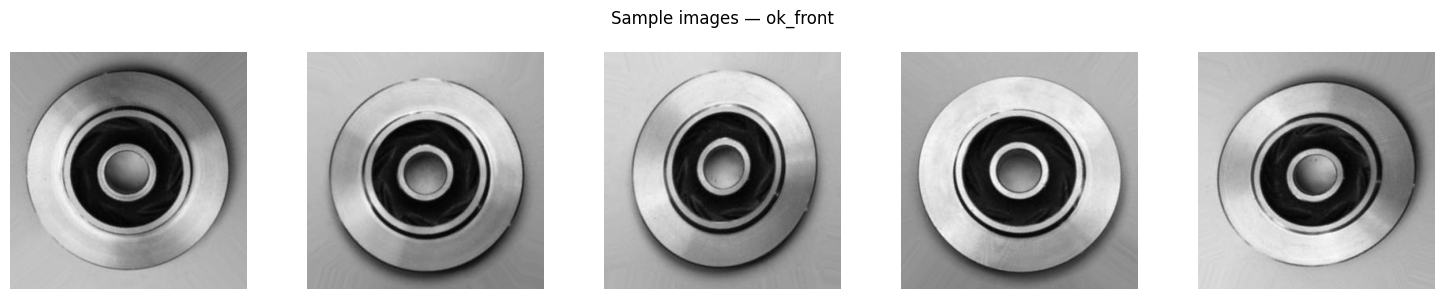

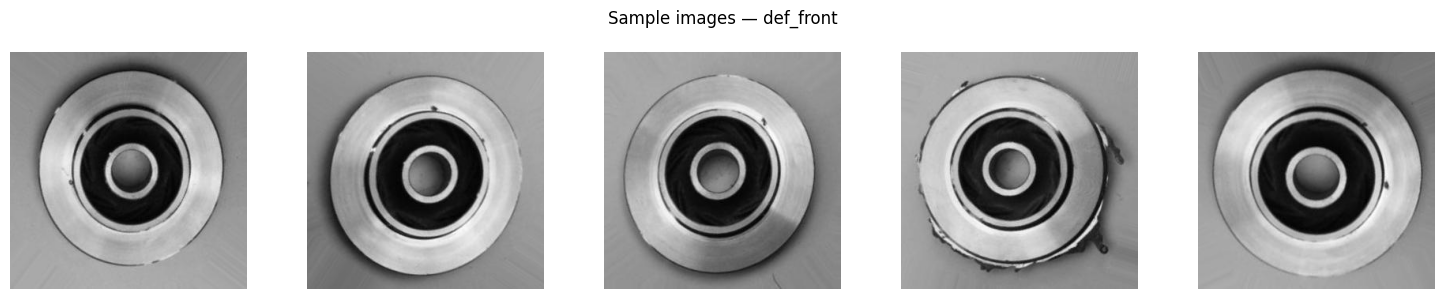

In [67]:
def show_samples(directory, cls, n=5):
    folder = os.path.join(directory, cls)
    files = random.sample(os.listdir(folder), n)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for ax, fname in zip(axes, files):
        img = tf.keras.preprocessing.image.load_img(os.path.join(folder, fname))
        ax.imshow(img)
        ax.axis("off")
    fig.suptitle(f"Sample images — {cls}")
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, "ok_front")
show_samples(TRAIN_DIR, "def_front")

In [68]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
])

In [69]:
def build_custom_cnn():
    inputs = layers.Input(shape=(224,224,3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

custom_model = build_custom_cnn()
custom_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,465 (400.25 KB)

 Trainable params: 102,017 (398.50 KB)

 Non-trainable params: 448 (1.75 KB)

In [70]:
custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
]

print("🔄 Training Custom CNN...")
history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

🔄 Training Custom CNN...
Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 43s 201ms/step - accuracy: 0.7983 - loss: 0.4693 - val_accuracy: 0.5901 - val_loss: 0.9753 - learning_rate: 0.0010
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.8248 - loss: 0.4224 - val_accuracy: 0.5901 - val_loss: 1.2534 - learning_rate: 0.0010
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 152ms/step - accuracy: 0.8325 - loss: 0.3903 - val_accuracy: 0.5901 - val_loss: 1.8667 - learning_rate: 0.0010
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 153ms/step - accuracy: 0.8414 - loss: 0.3548 - val_accuracy: 0.6247 - val_loss: 0.5928 - learning_rate: 0.0010
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 153ms/step - accuracy: 0.8504 - loss: 0.3397 - val_accuracy: 0.5968 - val_loss: 3.2994 - learning_rate: 0.0010
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 153ms/step - accuracy: 0.8706 - loss: 0.3079 - val_accuracy: 0.7460 - val_loss: 0.5902 - learning_rate: 0.0010
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 25s 1

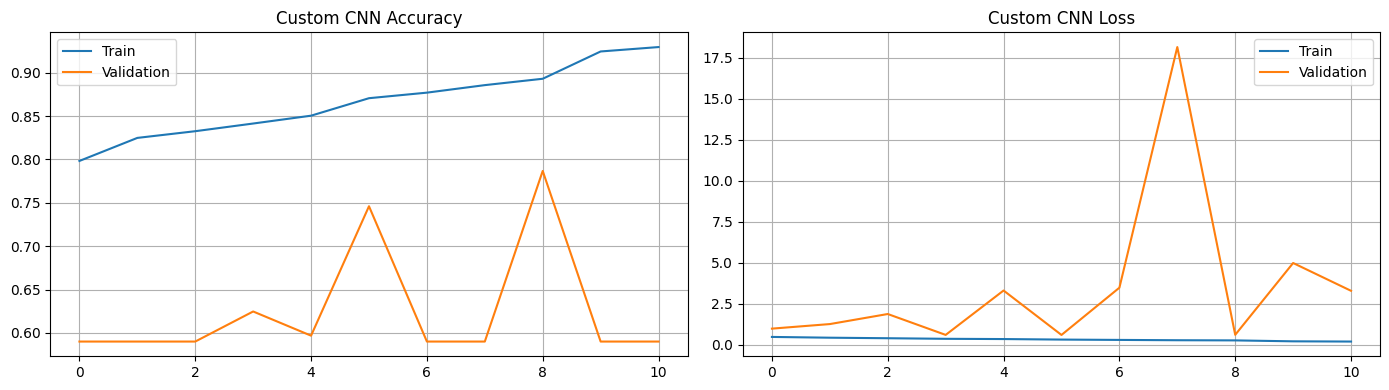

In [71]:
def plot_history(h, title=""):
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,4))
    ax1.plot(h.history['accuracy'], label='Train')
    ax1.plot(h.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} Accuracy'); ax1.legend(); ax1.grid(True)

    ax2.plot(h.history['loss'], label='Train')
    ax2.plot(h.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} Loss'); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_custom, "Custom CNN")

Custom CNN - EVALUATION
Test Accuracy: 0.7692
AUC Score: 0.9326

Classification Report:
              precision    recall  f1-score   support

    ok_front       0.90      0.42      0.57       262
   def_front       0.74      0.97      0.84       453

    accuracy                           0.77       715
   macro avg       0.82      0.69      0.71       715
weighted avg       0.80      0.77      0.74       715


CONFUSION MATRIX (4 numbers)
              Pred: ok_front   Pred: def_front
Actual ok_front :    109             153
Actual def_front :     12             441
True Negatives (TN)  : 109  → ok_front correct
False Positives (FP) : 153  → ok_front wrongly as defective
False Negatives (FN) : 12  → defective wrongly as ok_front
True Positives (TP)  : 441  → defective correct


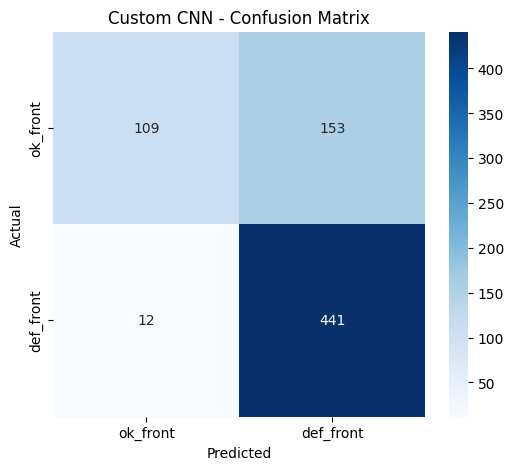

In [72]:
# --- FIXED: Extract labels correctly ---
def evaluate_model(model, dataset, name="Model"):
    # Get predictions
    y_probs = model.predict(dataset, verbose=0).flatten()
    y_pred = (y_probs >= 0.5).astype(int)

    # FIX: Extract labels properly from dataset
    y_true = []
    for _, labels in dataset:
        y_true.extend(labels.numpy().flatten().tolist())
    y_true = np.array(y_true).astype(int)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)

    print("="*60)
    print(f"{name} - EVALUATION")
    print("="*60)
    print(f"Test Accuracy: {acc:.4f}")
    print(f"AUC Score: {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion Matrix - 4 numbers
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("\n" + "="*50)
    print("CONFUSION MATRIX (4 numbers)")
    print("="*50)
    print(f"              Pred: {CLASS_NAMES[0]}   Pred: {CLASS_NAMES[1]}")
    print(f"Actual {CLASS_NAMES[0]} : {tn:>6}          {fp:>6}")
    print(f"Actual {CLASS_NAMES[1]} : {fn:>6}          {tp:>6}")
    print("="*50)
    print(f"True Negatives (TN)  : {tn}  → ok_front correct")
    print(f"False Positives (FP) : {fp}  → ok_front wrongly as defective")
    print(f"False Negatives (FN) : {fn}  → defective wrongly as ok_front")
    print(f"True Positives (TP)  : {tp}  → defective correct")
    print("="*50)

    # Plot
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return y_true, y_probs

# Run evaluation
custom_true, custom_probs = evaluate_model(custom_model, test_ds, "Custom CNN")

In [73]:
base_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_mobilenet.trainable = False

mobilenet_model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Rescaling(1./127.5, offset=-1),  # MobileNet expects [-1,1]
    base_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [74]:
print("🔄 Training MobileNetV2...")
history_mobilenet = mobilenet_model.fit(
    train_ds,  # Note: train_ds has [0,1] scaling, but MobileNet has its own Rescaling layer
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

🔄 Training MobileNetV2...
Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 104s 414ms/step - accuracy: 0.7395 - loss: 0.5195 - val_accuracy: 0.8983 - val_loss: 0.2960 - learning_rate: 1.0000e-04
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8730 - loss: 0.3127 - val_accuracy: 0.9420 - val_loss: 0.1996 - learning_rate: 1.0000e-04
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9032 - loss: 0.2398 - val_accuracy: 0.9548 - val_loss: 0.1582 - learning_rate: 1.0000e-04
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9237 - loss: 0.2004 - val_accuracy: 0.9661 - val_loss: 0.1291 - learning_rate: 1.0000e-04
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9345 - loss: 0.1763 - val_accuracy: 0.9721 - val_loss: 0.1105 - learning_rate: 1.0000e-04
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9422 - loss: 0.1581 - val_accuracy: 0.9751 - val_loss: 0.0974 - learning_rate: 1.0000e-04
Epoch 7/10
166/166 ━━━━━━━━━━

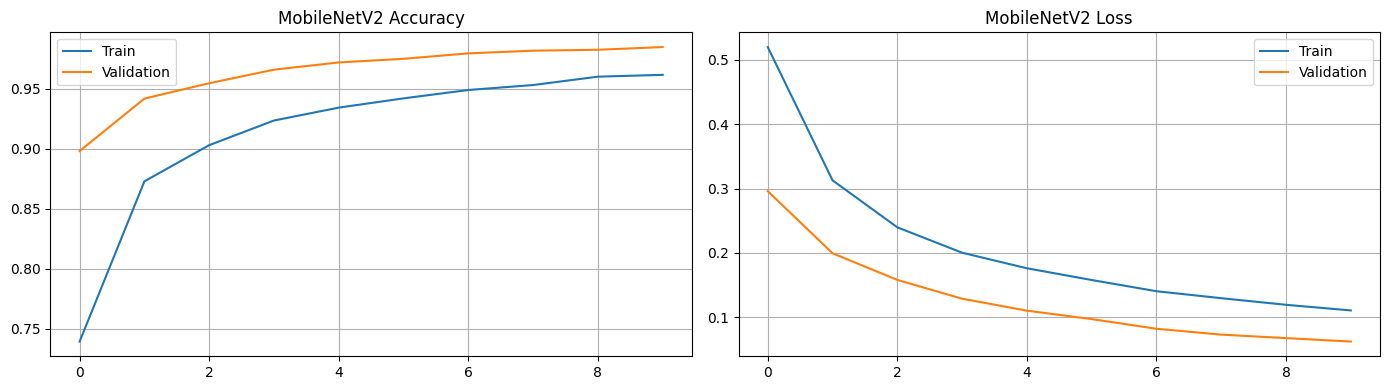

In [75]:
plot_history(history_mobilenet, title="MobileNetV2")

MobileNetV2 - EVALUATION
Test Accuracy: 0.9790
AUC Score: 0.9977

Classification Report:
              precision    recall  f1-score   support

    ok_front       0.95      0.99      0.97       262
   def_front       1.00      0.97      0.98       453

    accuracy                           0.98       715
   macro avg       0.97      0.98      0.98       715
weighted avg       0.98      0.98      0.98       715


CONFUSION MATRIX (4 numbers)
              Pred: ok_front   Pred: def_front
Actual ok_front :    260               2
Actual def_front :     13             440
True Negatives (TN)  : 260  → ok_front correct
False Positives (FP) : 2  → ok_front wrongly as defective
False Negatives (FN) : 13  → defective wrongly as ok_front
True Positives (TP)  : 440  → defective correct


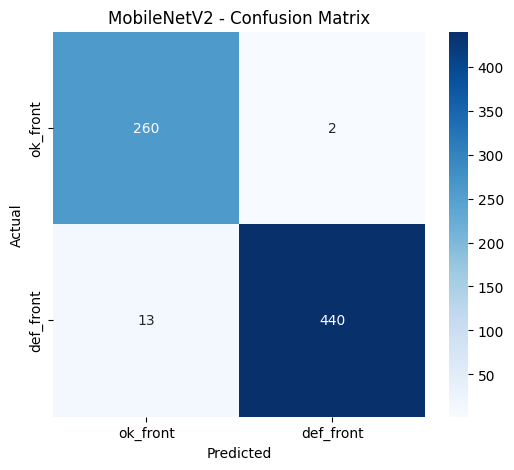

In [76]:
mobilenet_true, mobilenet_probs = evaluate_model(mobilenet_model, test_ds, "MobileNetV2")

In [77]:
custom_acc = accuracy_score(custom_true, (custom_probs>=0.5).astype(int))
mobilenet_acc = accuracy_score(mobilenet_true, (mobilenet_probs>=0.5).astype(int))

print("="*50)
print("FINAL COMPARISON")
print("="*50)
print(f"Custom CNN   -> Test Accuracy: {custom_acc:.4f}")
print(f"MobileNetV2  -> Test Accuracy: {mobilenet_acc:.4f}")
print("="*50)

if custom_acc > mobilenet_acc:
    print(" Custom CNN is better")
else:
    print(" MobileNetV2 is better")

FINAL COMPARISON
Custom CNN   -> Test Accuracy: 0.7692
MobileNetV2  -> Test Accuracy: 0.9790
🏆 MobileNetV2 is better


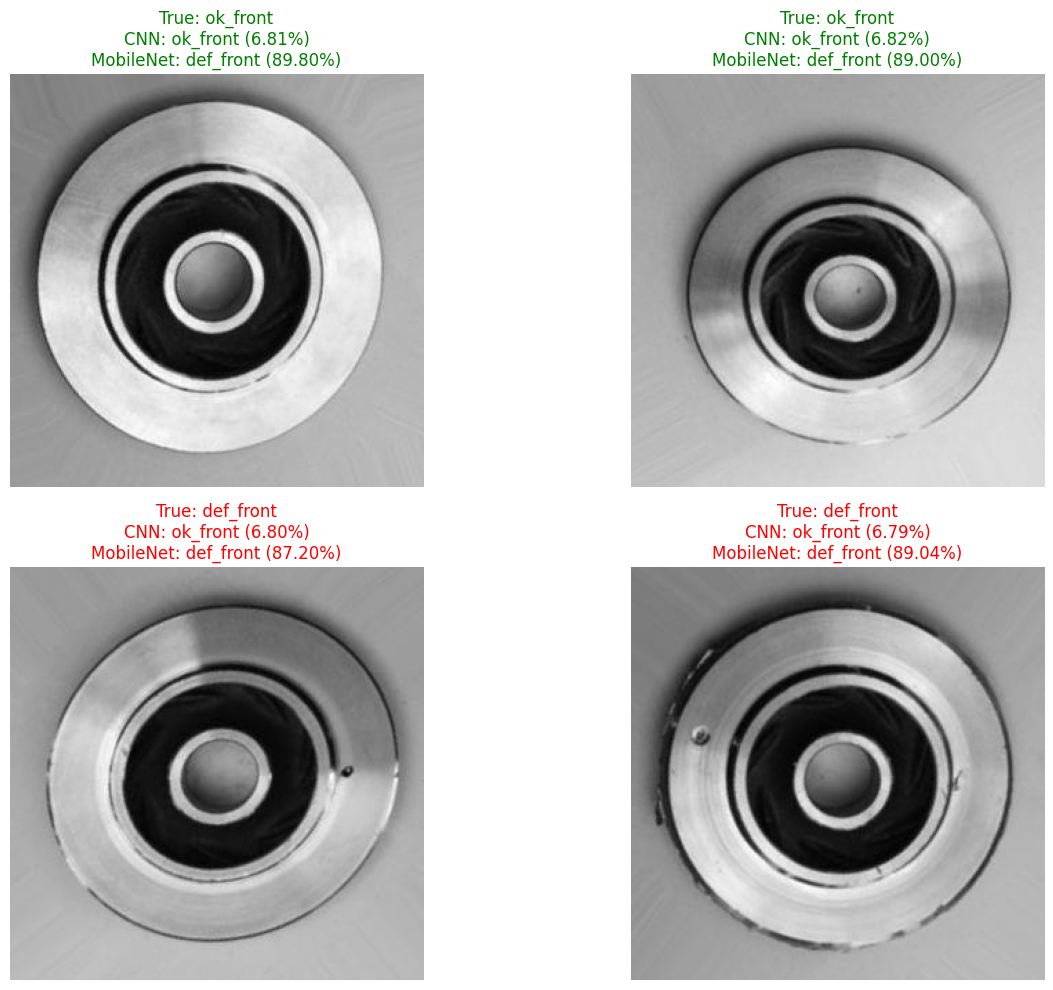

In [78]:

#  PREDICT ON SAMPLE IMAGES


def predict_single(model, image_path, threshold=0.5):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    prob = model.predict(arr, verbose=0)[0][0]
    pred_class = CLASS_NAMES[1] if prob >= threshold else CLASS_NAMES[0]
    return pred_class, prob

# Pick 4 random images from test set (2 from each class)
sample_images = []
for cls in CLASS_NAMES:
    folder = os.path.join(TEST_DIR, cls)
    files = random.sample(os.listdir(folder), 2)
    sample_images.extend([(os.path.join(folder, f), cls) for f in files])

# Display predictions from both models
plt.figure(figsize=(14, 10))
for i, (img_path, true_cls) in enumerate(sample_images):
    # Custom CNN prediction
    pred_cnn, prob_cnn = predict_single(custom_model, img_path)
    # MobileNetV2 prediction
    pred_mob, prob_mob = predict_single(mobilenet_model, img_path)

    img = tf.keras.preprocessing.image.load_img(img_path)
    plt.subplot(2, len(sample_images)//2, i+1)
    plt.imshow(img)
    plt.axis('off')
    title = f"True: {true_cls}\n"
    title += f"CNN: {pred_cnn} ({prob_cnn:.2%})\n"
    title += f"MobileNet: {pred_mob} ({prob_mob:.2%})"
    plt.title(title, color='green' if true_cls==pred_cnn else 'red')
plt.tight_layout()
plt.show()

In [79]:

# CELL 16: SAVE MODELS

custom_model.save('final_custom_cnn.keras')
mobilenet_model.save('final_mobilenet.keras')
print(" Models saved as:")
print("   - final_custom_cnn.keras")
print("   - final_mobilenet.keras")

# Optional: Download models to local PC
from google.colab import files
files.download('final_custom_cnn.keras')
files.download('final_mobilenet.keras')

 Models saved as:
   - final_custom_cnn.keras
   - final_mobilenet.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
# ------------------------------
# CELL 17: FINAL COMPARISON TABLE
# ------------------------------

# Extract best validation metrics
custom_val_acc = max(history_custom.history['val_accuracy'])
custom_val_loss = min(history_custom.history['val_loss'])

mobilenet_val_acc = max(history_mobilenet.history['val_accuracy'])
mobilenet_val_loss = min(history_mobilenet.history['val_loss'])

# Test accuracies (from cell 14)
custom_test_acc = accuracy_score(custom_true, (custom_probs >= 0.5).astype(int))
mobilenet_test_acc = accuracy_score(mobilenet_true, (mobilenet_probs >= 0.5).astype(int))

# Build comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Custom CNN', 'MobileNetV2'],
    'Val Accuracy': [custom_val_acc, mobilenet_val_acc],
    'Test Accuracy': [custom_test_acc, mobilenet_test_acc],
    'Val Loss': [custom_val_loss, mobilenet_val_loss]
})

print("="*60)
print("📊 FINAL MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Determine winner
if custom_test_acc > mobilenet_test_acc:
    winner = "Custom CNN"
elif mobilenet_test_acc > custom_test_acc:
    winner = "MobileNetV2"
else:
    winner = "Both models have equal accuracy"

print(f" Winner: {winner}")

# Print confusion matrices again for reference
print("\nCustom CNN Confusion Matrix:")
print(confusion_matrix(custom_true, (custom_probs >= 0.5).astype(int)))
print("\nMobileNetV2 Confusion Matrix:")
print(confusion_matrix(mobilenet_true, (mobilenet_probs >= 0.5).astype(int)))

📊 FINAL MODEL COMPARISON
      Model  Val Accuracy  Test Accuracy  Val Loss
 Custom CNN      0.786737       0.769231  0.590150
MobileNetV2      0.984928       0.979021  0.062587
🏆 Winner: MobileNetV2

Custom CNN Confusion Matrix:
[[109 153]
 [ 12 441]]

MobileNetV2 Confusion Matrix:
[[260   2]
 [ 13 440]]
